# Vehicle Dataset from CarDekho

## Dataset Overview
This dataset contains information about used cars listed on CarDekho, one of India's leading car search platforms. It includes details about vehicle specifications, pricing, and ownership history.

**Source:** [Kaggle - Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)


## Data Dictionary

| Column | Data Type | Description |
|--------|-----------|-------------|
| **name** | object | Complete name and model of the vehicle |
| **year** | int64 | Manufacturing year of the vehicle |
| **selling_price** | int64 | Current selling price (in INR) |
| **km_driven** | int64 | Total kilometers driven by the vehicle |
| **fuel** | object | Fuel type (Petrol, Diesel, CNG, LPG, Electric) |
| **seller_type** | object | Type of seller (Individual, Dealer, Trustmark Dealer) |
| **transmission** | object | Transmission type (Manual, Automatic) |
| **owner** | object | Ownership history (First Owner, Second Owner, etc.) |


## Dataset Statistics
- **Total Records:** 4,340 vehicles
- **Time Period:** Various years (check `year` column for range)
- **No Missing Values:** All columns are complete (4,340 non-null entries)


## Potential Analysis Questions
- What factors most influence vehicle selling price?
- How does depreciation vary by brand, fuel type, or transmission?
- What's the relationship between km_driven and selling_price?
- Which seller types offer better deals?
- How does ownership history affect pricing?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Getting the data - loading Df

In [2]:
vehicles_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/vehicles/data/CAR%20DETAILS%20FROM%20CAR%20DEKHO.csv"
vehicles = pd.read_csv(vehicles_url, usecols=lambda col: not col.startswith("Unnamed"))

In [3]:
vehicles

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


### Data inspection / EDA (Exploratory Data Analysis)

In [4]:
vehicles.shape

(4340, 8)

In [5]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


#### Numeric columns

In [6]:
vehicles.select_dtypes("number").describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Categorical columns

In [7]:
for col in ["fuel", "seller_type", "transmission", "owner"]:
    display(vehicles[col].value_counts(normalize=True, dropna=False).head(15).round(5))

fuel
Diesel      0.49608
Petrol      0.48917
CNG         0.00922
LPG         0.00530
Electric    0.00023
Name: proportion, dtype: float64

seller_type
Individual          0.74747
Dealer              0.22903
Trustmark Dealer    0.02350
Name: proportion, dtype: float64

transmission
Manual       0.89677
Automatic    0.10323
Name: proportion, dtype: float64

owner
First Owner             0.65253
Second Owner            0.25484
Third Owner             0.07005
Fourth & Above Owner    0.01866
Test Drive Car          0.00392
Name: proportion, dtype: float64

### Train set / Test set split

In [8]:
from sklearn.model_selection import train_test_split

vehicles_set = vehicles.copy()

train_set, test_set = train_test_split(vehicles_set, test_size=0.2, random_state=42)

vehicles_train = train_set.copy()
vehicles_test = test_set.copy()

#### Plots

In [ ]:
# Log-transform price (prices are right-skewed; use log1p for zeros)
vehicles_train['log_price'] = np.log1p(vehicles_train['selling_price'])


# Sort categories by median price (intuitive order)
def median_order(col):
    return vehicles_train.groupby(col)['log_price'].median().sort_values(ascending=False).index

cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in cat_cols:
    vehicles_train[f'{col}_order'] = vehicles_train[col].astype('category').cat.set_categories(median_order(col), ordered=True)

In [10]:
sns.set_color_codes("bright")

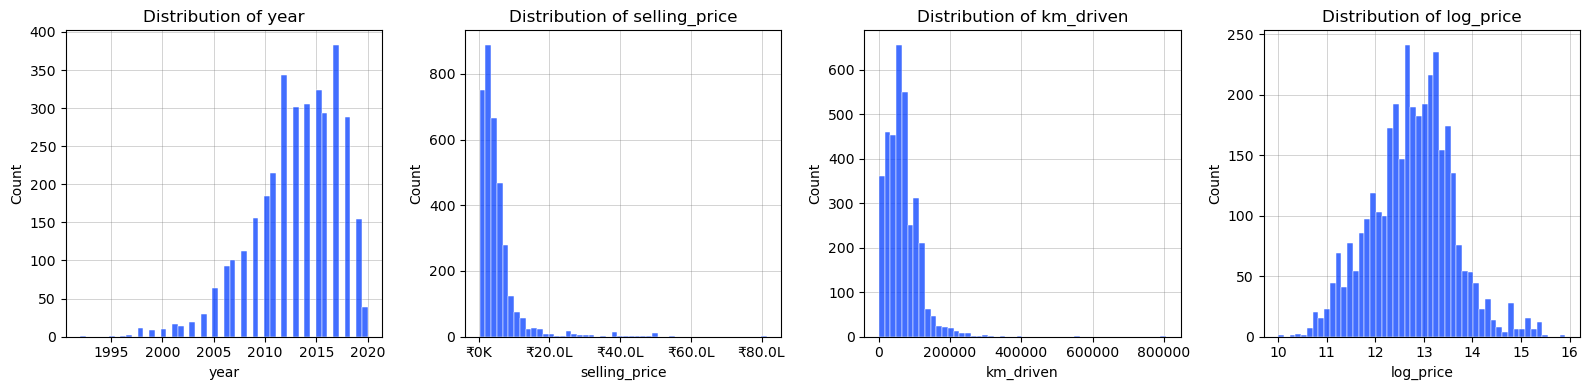

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
axes = axes.flatten()

numeric_cols = [col for col in vehicles_train.select_dtypes("number").columns if col in ["year", "selling_price", "km_driven", "log_price"]]
for i, col in enumerate(numeric_cols):
    sns.histplot(data=vehicles_train, x=col, color="b", edgecolor="white", bins=50, ax=axes[i])    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(col)
    axes[i].grid(True, alpha=0.4, linewidth=0.6, color="grey")
    axes[i].set_axisbelow(True)
    
    # Format selling_price axis to show prices in a readable format
    if col == "selling_price":
        axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/100000:.1f}L' if x >= 100000 else f'₹{x/1000:.0f}K'))
        
plt.tight_layout()
plt.show()

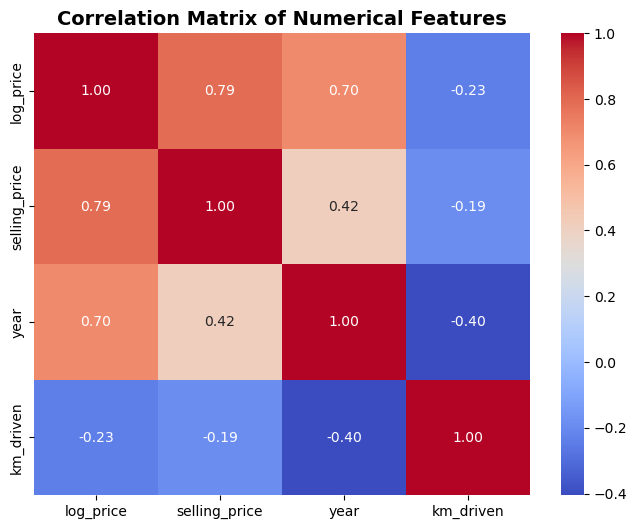

In [19]:
corr_matrix = vehicles_train[["log_price", "selling_price", "year", "km_driven"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix of Numerical Features", fontweight="bold", fontsize=14)
plt.show()

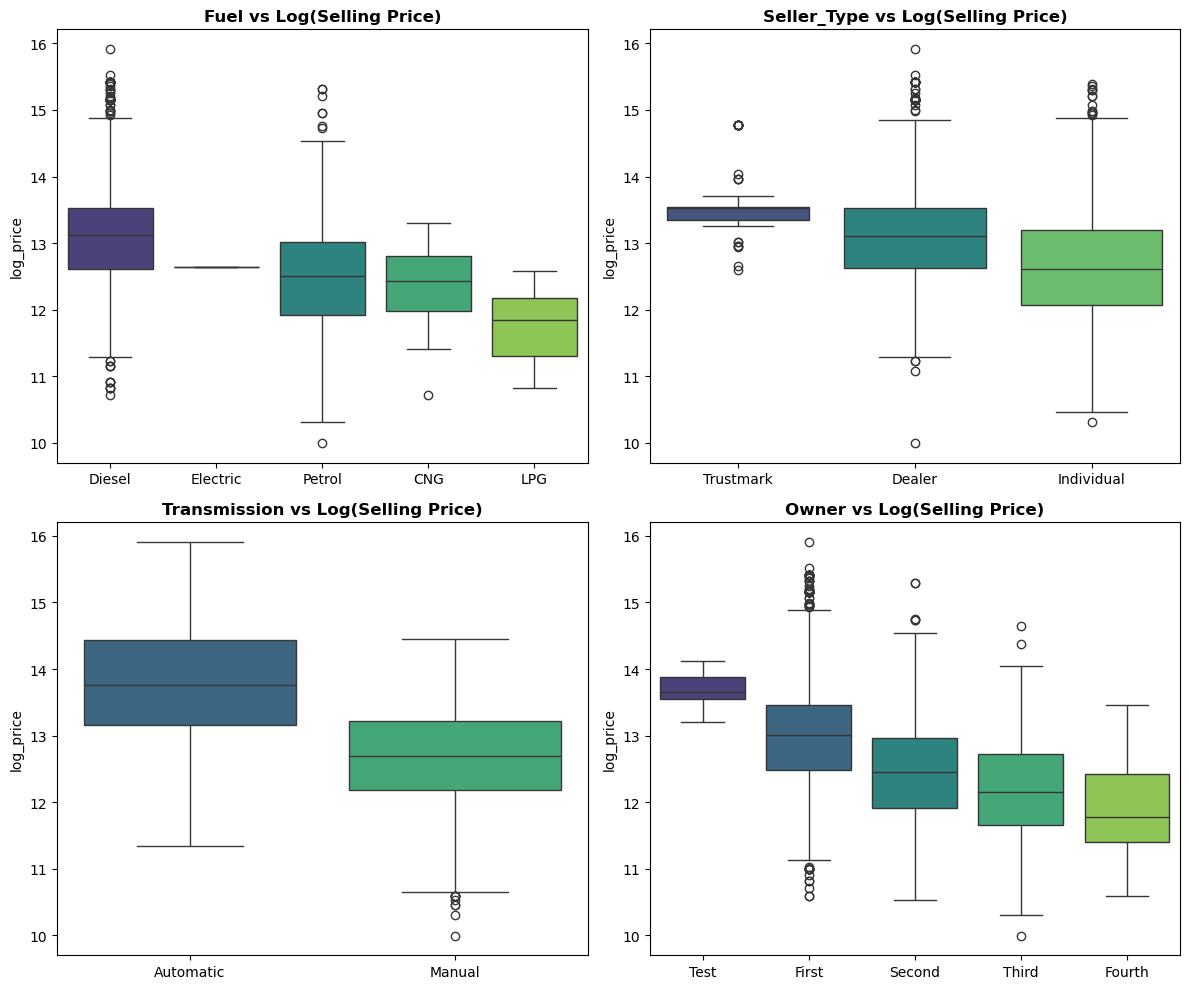

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=vehicles_train, x=col + '_order', y='log_price', hue=col + '_order', palette='viridis', ax=axes[i], legend=False)
    axes[i].set_title(f'{col.title()} vs Log(Selling Price)', fontweight='bold')
    axes[i].set_xlabel('')
    
    # Get current tick labels and modify them
    labels = [label.get_text().split()[0] for label in axes[i].get_xticklabels()]
    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()

In [26]:
order_cols = [col for col in vehicles_train.columns if col.endswith('_order')]
vehicles_train.drop(columns=order_cols, inplace=True)
print(f"Dropped: {order_cols}")

Dropped: ['fuel_order', 'seller_type_order', 'transmission_order', 'owner_order']


In [ ]:
# Calculate the vehicle's age to serve as a numerical feature for price prediction
vehicles_train["car_age"] = 2025 - vehicles_train["year"]

# Extract the manufacturer brand from the full name to create a higher-level categorical feature
vehicles_train["brand"] = vehicles_train["name"].str.split().str[0]

### Separate Features and Target Variable

In [33]:
vehicles_X = vehicles_train.drop(columns=["selling_price", "log_price", "name"])
vehicles_y = vehicles_train["log_price"]

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin


# Prices are often right-skewed; log transformation helps normalize the distribution for better model performance.
class LogPriceTransformer(BaseEstimator, TransformerMixin):        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["log_price"] = np.log1p(X["selling_price"])
        return X


# Converting manufacturing year to age provides a more intuitive numerical feature representing vehicle wear and depreciation.
class YearToAgeTransformer(BaseEstimator, TransformerMixin):    
    def __init__(self, current_year=2025):
        self.current_year = current_year

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["car_age"] = self.current_year - X["year"]
        return X


# Extracting the brand reduces the high cardinality of the full vehicle name into a more manageable categorical feature.
class BrandExtractor(BaseEstimator, TransformerMixin):    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["brand"] = X["name"].str.split().str[0]
        return X

In [34]:
categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]
numerical_cols = ["km_driven", "car_age"]